In [ ]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.9 MB/s eta 0:00:00


23.3333333333333


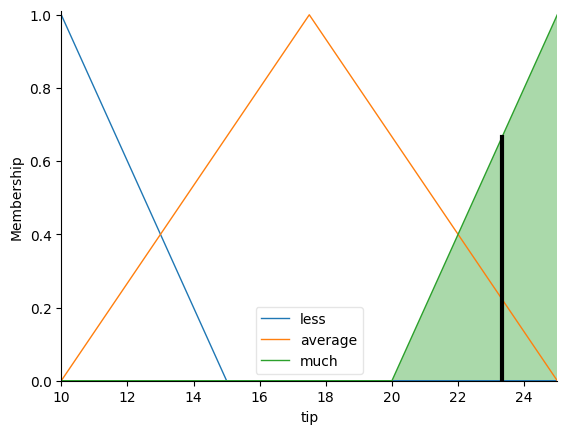

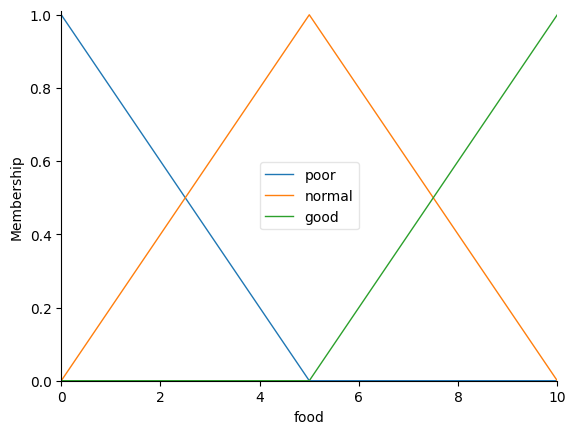

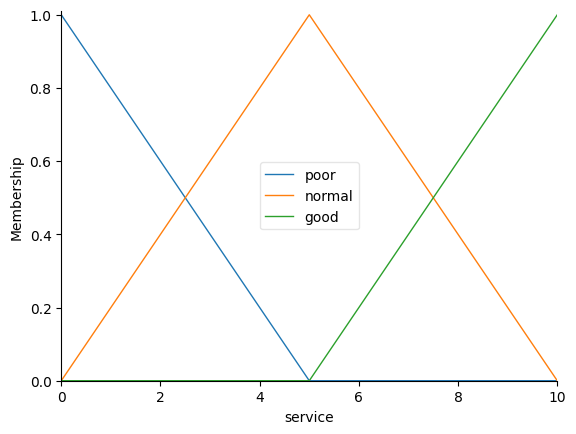

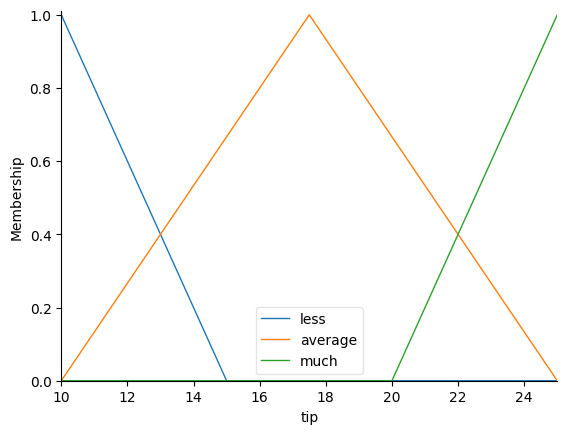

In [7]:
import skfuzzy as fuzz
from  skfuzzy import control as ctrl
import numpy as np
food=ctrl.Antecedent(np.arange(0,10.1,0.1),'food')
service=ctrl.Antecedent(np.arange(0,10.1,0.1),'service')
tip=ctrl.Consequent(np.arange(10,25.1,0.1),'tip')

food['poor']=fuzz.trimf(food.universe,[0,0,5])
food['normal']=fuzz.trimf(food.universe,[0,5,10])
food['good']=fuzz.trimf(food.universe,[5,10,10])

service['poor']=fuzz.trimf(service.universe,[0,0,5])
service['normal']=fuzz.trimf(service.universe,[0,5,10])
service['good']=fuzz.trimf(service.universe,[5,10,10])

tip['less']=fuzz.trimf(tip.universe,[10,10,15])
tip['average']=fuzz.trimf(tip.universe,[10,17.5,25])
tip['much']=fuzz.trimf(tip.universe,[20,25,25])

rule1=ctrl.Rule(food['poor']&service['poor'],tip['less'])
rule2=ctrl.Rule(food['poor']&service['normal'],tip['less'])
rule3=ctrl.Rule(food['poor']&service['good'],tip['average'])
rule4=ctrl.Rule(food['normal']&service['poor'],tip['less'])
rule5=ctrl.Rule(food['normal']&service['normal'],tip['average'])
rule6=ctrl.Rule(food['normal']&service['good'],tip['much'])
rule7=ctrl.Rule(food['good']&service['poor'],tip['average'])
rule8=ctrl.Rule(food['good']&service['normal'],tip['much'])
rule9=ctrl.Rule(food['good']&service['good'],tip['much'])

tipping_ctrl=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9])
tipping=ctrl.ControlSystemSimulation(tipping_ctrl)
tipping.input['food']=10
tipping.input['service']=10
tipping.compute()

print(tipping.output['tip'])
tip.view(sim=tipping)
food.view()
service.view()
tip.view()


Ước tính thời gian giặt: 41.00000000000001
Ước tính lượng nước: 83.33333333333336


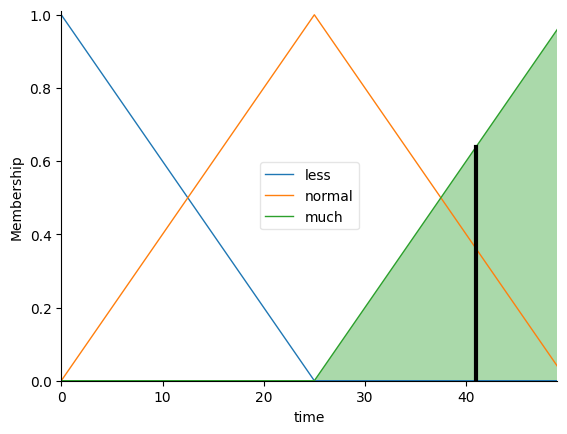

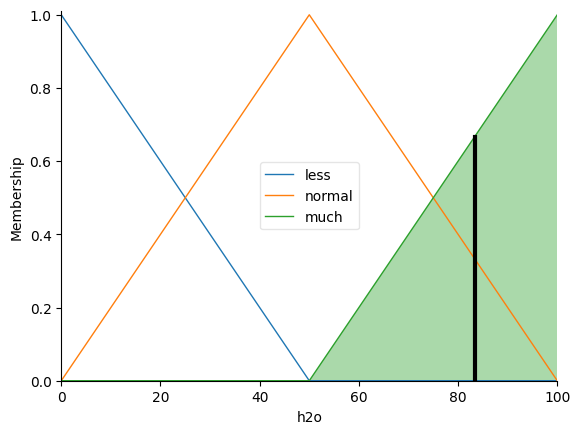

In [9]:
!pip install scikit-fuzzy

import skfuzzy as fuzz
from  skfuzzy import control as ctrl
import numpy as np
kluong=ctrl.Antecedent(np.arange(0,6.1,0.1),'khoiluong')
mdban=ctrl.Antecedent(np.arange(0,100.1,0.1),'mdban')
lvai=ctrl.Antecedent(np.arange(0,2.1,1),'lvai')

time=ctrl.Consequent(np.arange(0,50,1),'time')
h2o=ctrl.Consequent(np.arange(0,100.1,1),'h2o')

kluong['it']=fuzz.trimf(kluong.universe,[0,0,3])
kluong['tb']=fuzz.trimf(kluong.universe,[0,3,6])
kluong['nhieu']=fuzz.trimf(kluong.universe,[3,6,6])
mdban['do']=fuzz.trimf(mdban.universe,[0,0,50])
mdban['tb']=fuzz.trimf(mdban.universe,[0,50,100])
mdban['sach']=fuzz.trimf(mdban.universe,[50,100,100])
lvai['mem']=fuzz.trimf(lvai.universe,[0,0,0.5])
lvai['tb']=fuzz.trimf(lvai.universe,[0,1,1])
lvai['cung']=fuzz.trimf(lvai.universe,[1.5,2,2])

time['less']=fuzz.trimf(time.universe,[0,0,25])
time['normal']=fuzz.trimf(time.universe,[0,25,50])
time['much']=fuzz.trimf(time.universe,[25,50,50])
h2o['less']=fuzz.trimf(h2o.universe,[0,0,50])
h2o['normal']=fuzz.trimf(h2o.universe,[0,50,100])
h2o['much']=fuzz.trimf(h2o.universe,[50,100,100])

ctr1_time = ctrl.Rule(kluong['it'] & mdban['sach'] & lvai['mem'], time['less'])
ctr1_h2o = ctrl.Rule(kluong['it'] & mdban['sach'] & lvai['mem'], h2o['less'])
ctr2_time = ctrl.Rule(kluong['it'] & mdban['sach'] & lvai['tb'], time['normal'])
ctr2_h2o = ctrl.Rule(kluong['it'] & mdban['sach'] & lvai['tb'], h2o['normal'])
ctr3_time = ctrl.Rule(kluong['it'] & mdban['sach'] & lvai['cung'], time['normal'])
ctr3_h2o = ctrl.Rule(kluong['it'] & mdban['sach'] & lvai['cung'], h2o['normal'])
ctr4_time = ctrl.Rule(kluong['it'] & mdban['tb'] & lvai['mem'], time['normal'])
ctr4_h2o = ctrl.Rule(kluong['it'] & mdban['tb'] & lvai['mem'], h2o['normal'])
ctr5_time = ctrl.Rule(kluong['it'] & mdban['tb'] & lvai['tb'], time['normal'])
ctr5_h2o = ctrl.Rule(kluong['it'] & mdban['tb'] & lvai['tb'], h2o['normal'])
ctr6_time = ctrl.Rule(kluong['it'] & mdban['tb'] & lvai['cung'], time['normal'])
ctr6_h2o = ctrl.Rule(kluong['it'] & mdban['tb'] & lvai['cung'], h2o['normal'])
ctr7_time = ctrl.Rule(kluong['it'] & mdban['do'] & lvai['mem'], time['normal'])
ctr7_h2o = ctrl.Rule(kluong['it'] & mdban['do'] & lvai['mem'], h2o['normal'])
ctr8_time = ctrl.Rule(kluong['it'] & mdban['do'] & lvai['tb'], time['much'])
ctr8_h2o = ctrl.Rule(kluong['it'] & mdban['do'] & lvai['tb'], h2o['much'])
ctr9_time = ctrl.Rule(kluong['it'] & mdban['do'] & lvai['cung'], time['much'])
ctr9_h2o = ctrl.Rule(kluong['it'] & mdban['do'] & lvai['cung'], h2o['much'])
ctr10_time = ctrl.Rule(kluong['tb'] & mdban['sach'] & lvai['mem'], time['normal'])
ctr10_h2o = ctrl.Rule(kluong['tb'] & mdban['sach'] & lvai['mem'], h2o['normal'])
ctr11_time = ctrl.Rule(kluong['tb'] & mdban['sach'] & lvai['tb'], time['normal'])
ctr11_h2o = ctrl.Rule(kluong['tb'] & mdban['sach'] & lvai['tb'], h2o['normal'])
ctr12_time = ctrl.Rule(kluong['tb'] & mdban['sach'] & lvai['cung'], time['normal'])
ctr12_h2o = ctrl.Rule(kluong['tb'] & mdban['sach'] & lvai['cung'], h2o['normal'])
ctr13_time = ctrl.Rule(kluong['tb'] & mdban['tb'] & lvai['mem'], time['normal'])
ctr13_h2o = ctrl.Rule(kluong['tb'] & mdban['tb'] & lvai['mem'], h2o['normal'])
ctr14_time = ctrl.Rule(kluong['tb'] & mdban['tb'] & lvai['tb'], time['normal'])
ctr14_h2o = ctrl.Rule(kluong['tb'] & mdban['tb'] & lvai['tb'], h2o['normal'])
ctr15_time = ctrl.Rule(kluong['tb'] & mdban['tb'] & lvai['cung'], time['much'])
ctr15_h2o = ctrl.Rule(kluong['tb'] & mdban['tb'] & lvai['cung'], h2o['much'])
ctr16_time = ctrl.Rule(kluong['tb'] & mdban['do'] & lvai['mem'], time['much'])
ctr16_h2o = ctrl.Rule(kluong['tb'] & mdban['do'] & lvai['mem'], h2o['much'])
ctr17_time = ctrl.Rule(kluong['tb'] & mdban['do'] & lvai['tb'], time['much'])
ctr17_h2o = ctrl.Rule(kluong['tb'] & mdban['do'] & lvai['tb'], h2o['much'])
ctr18_time = ctrl.Rule(kluong['tb'] & mdban['do'] & lvai['cung'], time['much'])
ctr18_h2o = ctrl.Rule(kluong['tb'] & mdban['do'] & lvai['cung'], h2o['much'])
ctr19_time = ctrl.Rule(kluong['nhieu'] & mdban['sach'] & lvai['mem'], time['normal'])
ctr19_h2o = ctrl.Rule(kluong['nhieu'] & mdban['sach'] & lvai['mem'], h2o['normal'])
ctr20_time = ctrl.Rule(kluong['nhieu'] & mdban['sach'] & lvai['tb'], time['much'])
ctr20_h2o = ctrl.Rule(kluong['nhieu'] & mdban['sach'] & lvai['tb'], h2o['much'])
ctr21_time = ctrl.Rule(kluong['nhieu'] & mdban['sach'] & lvai['cung'], time['much'])
ctr21_h2o = ctrl.Rule(kluong['nhieu'] & mdban['sach'] & lvai['cung'], h2o['much'])
ctr22_time = ctrl.Rule(kluong['nhieu'] & mdban['tb'] & lvai['mem'], time['much'])
ctr22_h2o = ctrl.Rule(kluong['nhieu'] & mdban['tb'] & lvai['mem'], h2o['much'])
ctr23_time = ctrl.Rule(kluong['nhieu'] & mdban['tb'] & lvai['tb'], time['much'])
ctr23_h2o = ctrl.Rule(kluong['nhieu'] & mdban['tb'] & lvai['tb'], h2o['much'])
ctr24_time = ctrl.Rule(kluong['nhieu'] & mdban['tb'] & lvai['cung'], time['much'])
ctr24_h2o = ctrl.Rule(kluong['nhieu'] & mdban['tb'] & lvai['cung'], h2o['much'])
ctr25_time = ctrl.Rule(kluong['nhieu'] & mdban['do'] & lvai['mem'], time['much'])
ctr25_h2o = ctrl.Rule(kluong['nhieu'] & mdban['do'] & lvai['mem'], h2o['much'])
ctr26_time = ctrl.Rule(kluong['nhieu'] & mdban['do'] & lvai['tb'], time['much'])
ctr26_h2o = ctrl.Rule(kluong['nhieu'] & mdban['do'] & lvai['tb'], h2o['much'])
ctr27_time = ctrl.Rule(kluong['nhieu'] & mdban['do'] & lvai['cung'], time['much'])
ctr27_h2o = ctrl.Rule(kluong['nhieu'] & mdban['do'] & lvai['cung'], h2o['much'])

washing_ctrl=ctrl.ControlSystem([
    ctr1_time, ctr1_h2o,
    ctr2_time, ctr2_h2o,
    ctr3_time, ctr3_h2o,
    ctr4_time, ctr4_h2o,
    ctr5_time, ctr5_h2o,
    ctr6_time, ctr6_h2o,
    ctr7_time, ctr7_h2o,
    ctr8_time, ctr8_h2o,
    ctr9_time, ctr9_h2o,
    ctr10_time, ctr10_h2o,
    ctr11_time, ctr11_h2o,
    ctr12_time, ctr12_h2o,
    ctr13_time, ctr13_h2o,
    ctr14_time, ctr14_h2o,
    ctr15_time, ctr15_h2o,
    ctr16_time, ctr16_h2o,
    ctr17_time, ctr17_h2o,
    ctr18_time, ctr18_h2o,
    ctr19_time, ctr19_h2o,
    ctr20_time, ctr20_h2o,
    ctr21_time, ctr21_h2o,
    ctr22_time, ctr22_h2o,
    ctr23_time, ctr23_h2o,
    ctr24_time, ctr24_h2o,
    ctr25_time, ctr25_h2o,
    ctr26_time, ctr26_h2o,
    ctr27_time, ctr27_h2o
])
washing=ctrl.ControlSystemSimulation(washing_ctrl)
washing.input['khoiluong']=6
washing.input['mdban']=100
washing.input['lvai']=2
washing.compute()
print("Ước tính thời gian giặt:", washing.output['time'])
print("Ước tính lượng nước:", washing.output['h2o'])
time.view(sim=washing)
h2o.view(sim=washing)